> **Analytical Note:** 
For high-level metrics (such as Total Job Postings, Median Salary, and Total Companies), please refer to the interactive Dashboard. This notebook is exclusively dedicated to a deep-dive analysis regarding workplace flexibility trends and the market valuation of technical skills.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
import warnings

In [12]:
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [13]:
# Set your GCP Project ID
project_id = "data-job-analytic-platform"

# Initializing the BigQuery Client using Application Default Credentials
try:
    client = bigquery.Client(project=project_id)
    print(f"✅ Successfully connected to GCP Project: {client.project}")
except Exception as e:
    print(f"❌ Failed to connect to BigQuery. Make sure you are logged in to GCP in the terminal. Error: {e}")

✅ Successfully connected to GCP Project: data-job-analytic-platform


In [14]:
def run_bq_query(sql_query):
    """
    Helper function to execute a SQL query on BigQuery 
    and automatically convert the result into a Pandas DataFrame.
    """
    try:
        df = client.query(sql_query).to_dataframe()
        return df
    except Exception as e:
        print(f"Error while executing query:\n{e}")
        return None

test_query = """
SELECT COUNT(*) AS total_job_postings
FROM `data-job-analytic-platform.mart_gold.fact_job_postings`
"""

print("Testing data extraction...")
df_test = run_bq_query(test_query)
display(df_test)

Testing data extraction...


,total_job_postings
0,1611848


## Chapter A: Who Are the Key Players in the Market? (Top 10 Aggressive Hirers per Role)

Rather than just looking at total volume, we need to break down which companies are the most massively expanding their teams for specific roles (such as Data Analyst, Data Engineer, or Data Scientist). 

To ensure memory efficiency, the *ranking* process is performed directly inside the Data Warehouse using a `Window Function` before the data is extracted into local memory (Pandas).

Pulling Top 10 Companies per Role data from BigQuery...


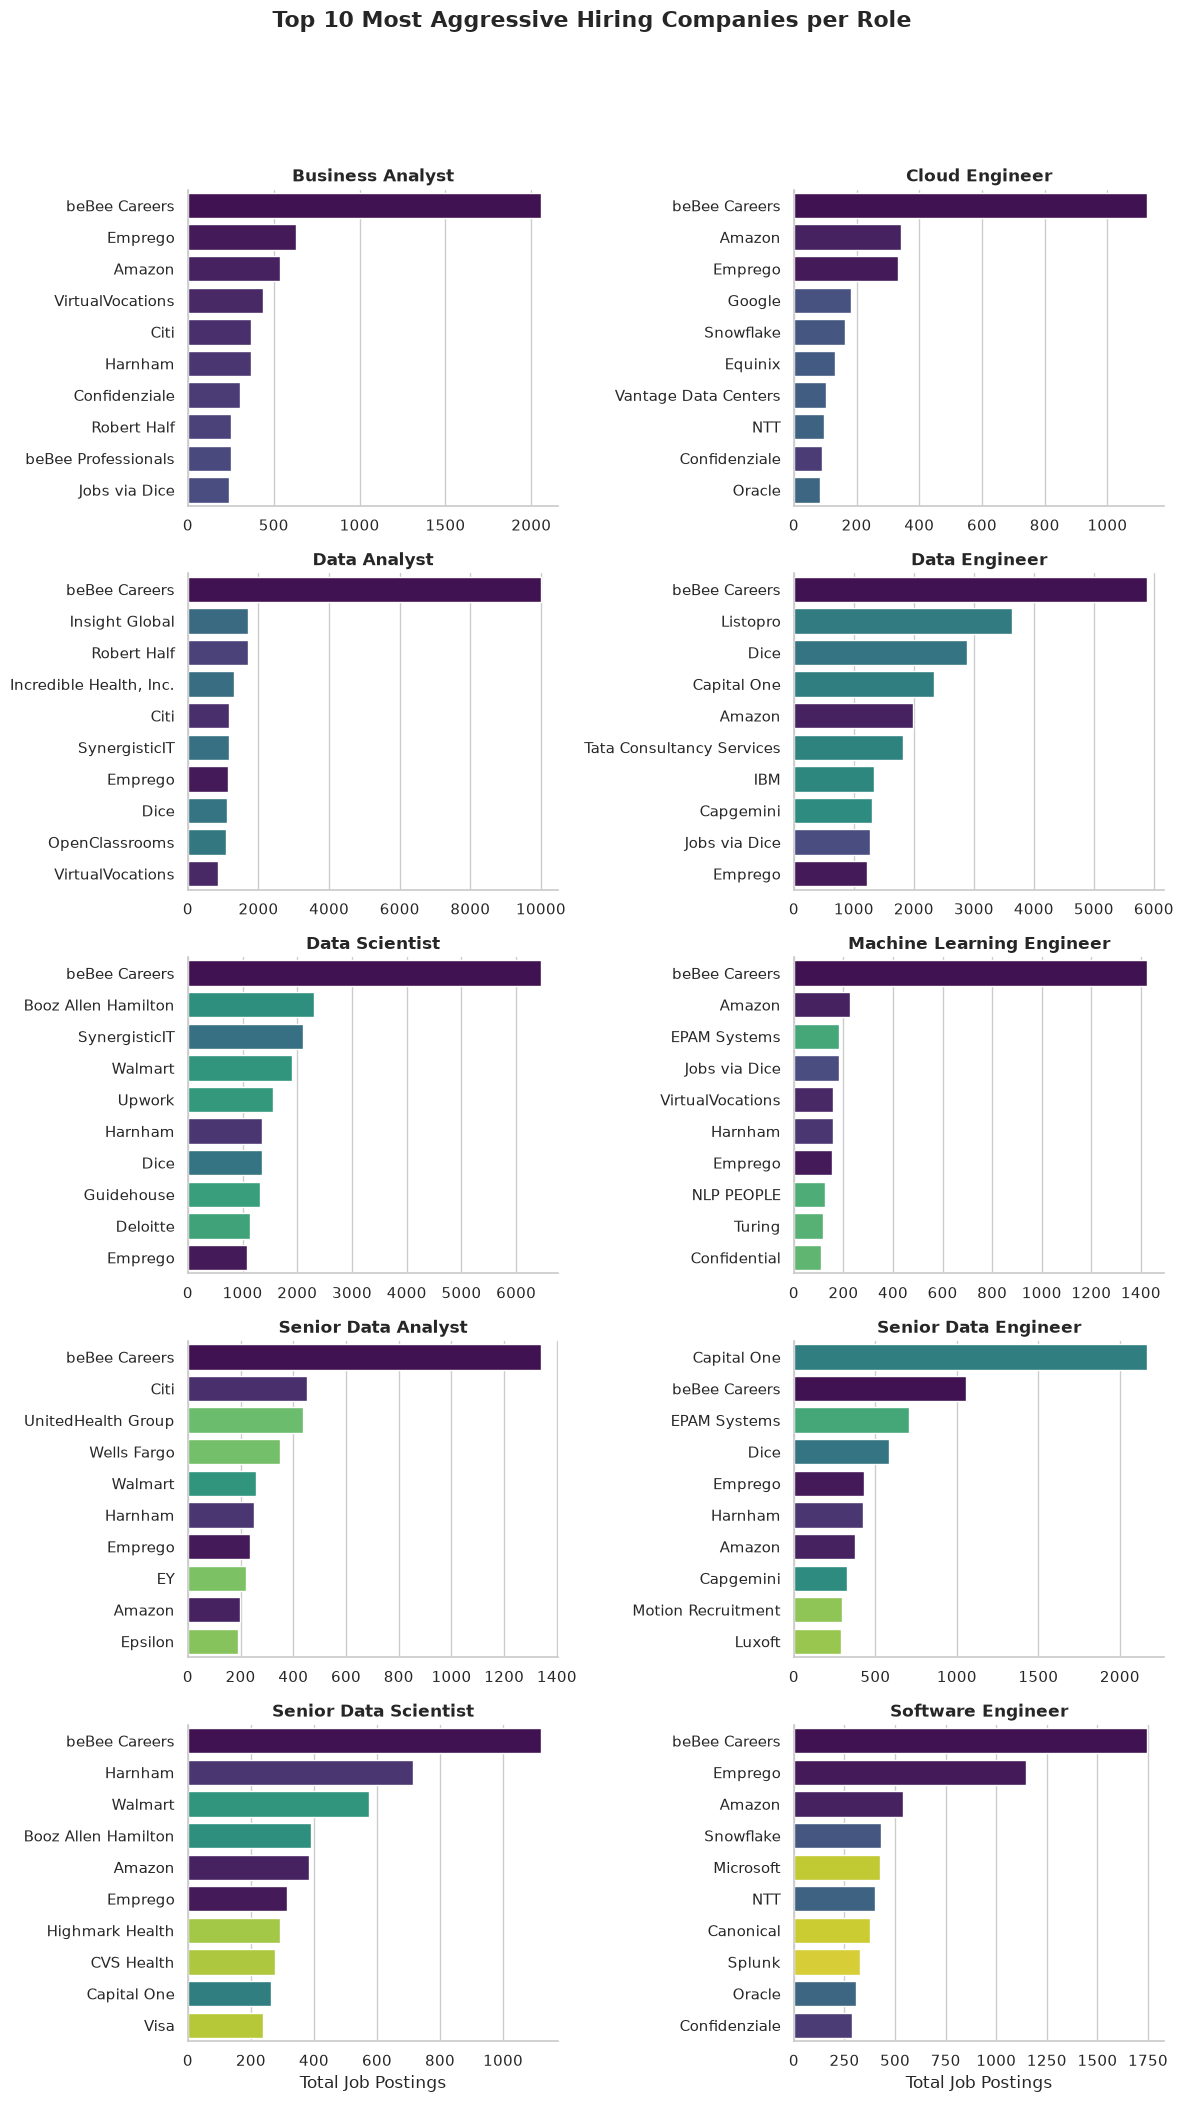

In [15]:
query_top_companies = """
WITH CompanyJobCounts AS (
    SELECT
        f.job_title_short,
        c.company_name,
        COUNT(f.job_id) AS total_postings
    FROM `data-job-analytic-platform.mart_gold.fact_job_postings` f
    INNER JOIN `data-job-analytic-platform.mart_gold.dim_company` c
        ON f.company_id = c.company_id
    GROUP BY
        f.job_title_short,
        c.company_name
),
RankedCompanies AS (
    SELECT
        job_title_short,
        company_name,
        total_postings,
        ROW_NUMBER() OVER(PARTITION BY job_title_short ORDER BY total_postings DESC) as rank
    FROM CompanyJobCounts
)
SELECT
    job_title_short,
    company_name,
    total_postings
FROM RankedCompanies
WHERE rank <= 10
ORDER BY
    job_title_short,
    rank;
"""

print("Pulling Top 10 Companies per Role data from BigQuery...")
df_top_companies = run_bq_query(query_top_companies)

g = sns.catplot(
    data=df_top_companies,
    x='total_postings',
    y='company_name',
    col='job_title_short',
    col_wrap=2,          
    kind='bar',
    sharey=False,        
    sharex=False,
    height=4,
    aspect=1.5,
    palette='viridis'
)

g.set_titles(col_template="{col_name}", size=12, fontweight='bold')
g.set_axis_labels("Total Job Postings", "")
plt.suptitle("Top 10 Most Aggressive Hiring Companies per Role", y=1.05, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Chapter B: Work Flexibility Trends & Their Impact on Compensation

Since the shift in work trends caused by the pandemic, how much *remote working* (WFH) adoption still remains in today's market? Beyond just the WFH vs WFO ratio, we need to investigate the possible *trade-off*: **Does the freedom to work from home come at the cost of health benefits (insurance) and average salary?**

Extracting WFH vs WFO aggregation from BigQuery...


,work_model,total_jobs,percentage_with_insurance,avg_salary
0,On-Site (WFO),43841,48.79,122391.49
1,Remote (WFH),7117,54.56,132412.58


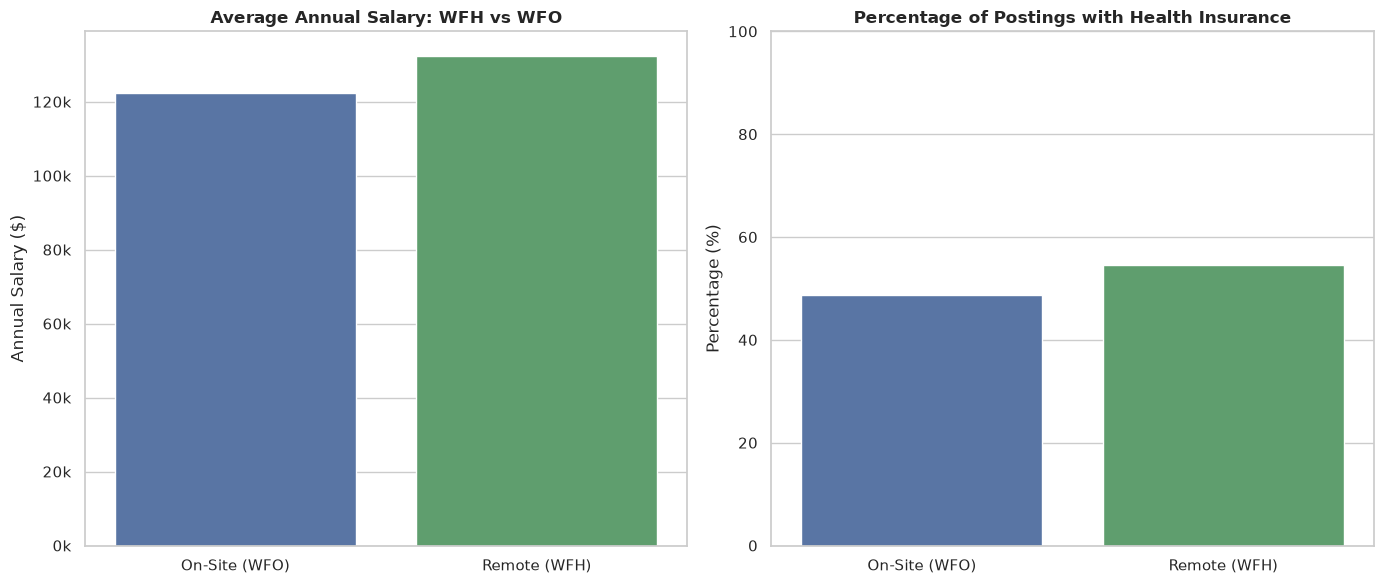

In [16]:
query_working_conditions = """
SELECT 
    CASE 
        WHEN job_work_from_home = TRUE THEN 'Remote (WFH)' 
        ELSE 'On-Site (WFO)' 
    END AS work_model,
    COUNT(job_id) AS total_jobs,
    ROUND(SAFE_DIVIDE(SUM(CASE WHEN job_health_insurance = TRUE THEN 1 ELSE 0 END), COUNT(job_id)) * 100, 2) AS percentage_with_insurance,
    ROUND(AVG(salary_year_avg), 2) AS avg_salary
FROM `data-job-analytic-platform.mart_gold.fact_job_postings`
WHERE salary_year_avg IS NOT NULL
GROUP BY job_work_from_home
ORDER BY total_jobs DESC;
"""

print("Extracting WFH vs WFO aggregation from BigQuery...")
df_conditions = run_bq_query(query_working_conditions)
display(df_conditions) 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=df_conditions, 
    x='work_model', 
    y='avg_salary', 
    ax=axes[0],
    palette=['#4C72B0', '#55A868']
)
axes[0].set_title('Average Annual Salary: WFH vs WFO', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Annual Salary ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}k".format(int(x/1000))))

sns.barplot(
    data=df_conditions, 
    x='work_model', 
    y='percentage_with_insurance', 
    ax=axes[1],
    palette=['#4C72B0', '#55A868']
)
axes[1].set_title('Percentage of Postings with Health Insurance', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_ylim(0, 100) 

plt.tight_layout()
plt.show()

## Chapter C: The Shift in Recruitment Paradigm (Degree vs No Degree)

Is a bachelor's degree still a mandatory golden ticket? We will evaluate the percentage of job postings that are starting to adopt skill-based recruitment (*skill-based hiring*) without requiring a degree, as well as look at which roles are the most progressive in this trend.

Evaluating academic degree requirement ratio...


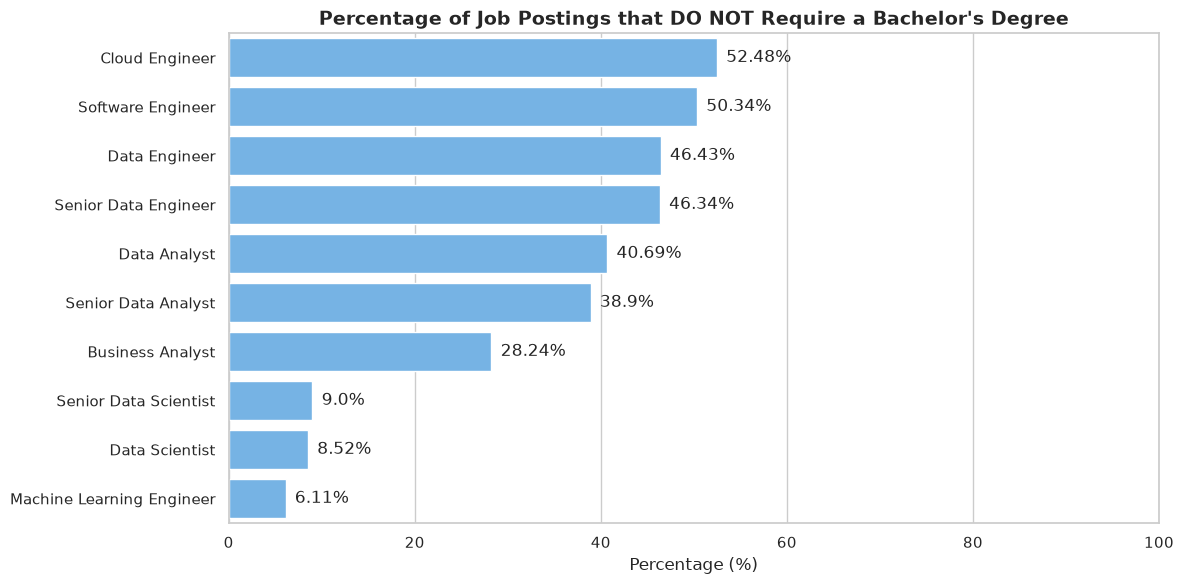

In [17]:
query_degree = """
SELECT 
    job_title_short,
    COUNT(*) AS total_jobs,
    ROUND(SAFE_DIVIDE(SUM(CASE WHEN job_no_degree_mention = TRUE THEN 1 ELSE 0 END), COUNT(*)) * 100, 2) AS percentage_no_degree
FROM `data-job-analytic-platform.mart_gold.fact_job_postings`
GROUP BY job_title_short
HAVING total_jobs > 1000 -- Filtering out small data anomalies
ORDER BY percentage_no_degree DESC;
"""

print("Evaluating academic degree requirement ratio...")
df_degree = run_bq_query(query_degree)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_degree,
    x='percentage_no_degree',
    y='job_title_short',
    color='#64B5F6'
)

plt.title('Percentage of Job Postings that DO NOT Require a Bachelor\'s Degree', fontweight='bold', fontsize=14)
plt.xlabel('Percentage (%)')
plt.ylabel('')
plt.xlim(0, 100)

for index, value in enumerate(df_degree['percentage_no_degree']):
    plt.text(value + 1, index, f"{value}%", va='center')

plt.tight_layout()
plt.show()

## Chapter D: Market Skill Valuation (Demand vs Compensation)

This section explores the intersection between market demand frequency (*market demand*) and financial compensation valuation. Data is pulled by joining the Fact Table, the Skill Dimension Table, and the *Bridge* Table, demonstrating the efficiency of the *Star Schema* architecture that has been built.

Running Window Function computation on BigQuery for all roles...


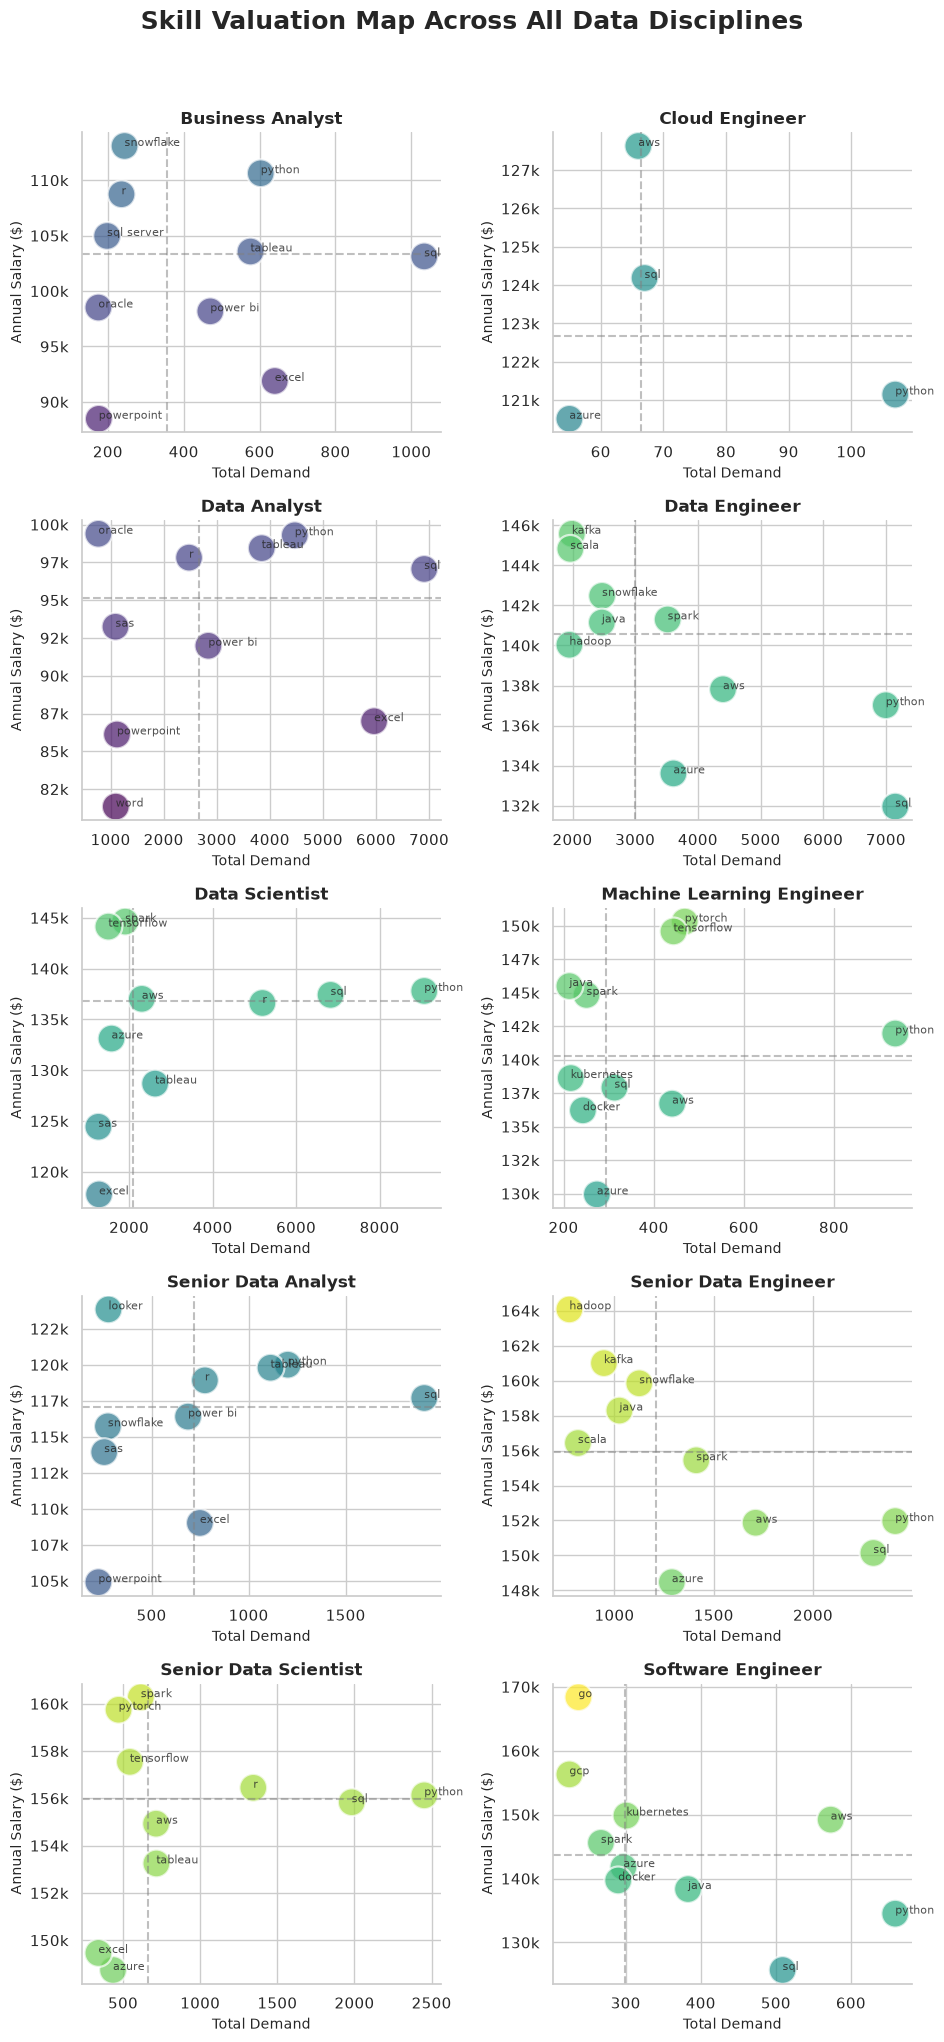

In [19]:
query_all_skills = """
WITH SkillStats AS (
    SELECT
        f.job_title_short,
        s.skill_name,
        COUNT(DISTINCT f.job_id) AS total_appear,
        AVG(f.salary_year_avg) AS avg_annual_salary
    FROM `data-job-analytic-platform.mart_gold.fact_job_postings` f
    INNER JOIN `data-job-analytic-platform.mart_gold.bridge_skill_job` b
        ON f.job_id = b.job_id
    INNER JOIN `data-job-analytic-platform.mart_gold.dim_skill` s
        ON b.skill_id = s.skill_id
    WHERE f.salary_year_avg IS NOT NULL
    GROUP BY 
        f.job_title_short,
        s.skill_name
    HAVING total_appear > 50 -- Lower bound so anomalous skills are excluded
),
RankedSkills AS (
    SELECT 
        job_title_short,
        skill_name,
        total_appear,
        avg_annual_salary,
        ROW_NUMBER() OVER(PARTITION BY job_title_short ORDER BY total_appear DESC) as rank
    FROM SkillStats
)
SELECT * 
FROM RankedSkills
WHERE rank <= 10 -- Taking only the Top 15 most in-demand skills per Role
ORDER BY job_title_short, rank;
"""

print("Running Window Function computation on BigQuery for all roles...")
df_all_skills = run_bq_query(query_all_skills)

g = sns.relplot(
    data=df_all_skills,
    x='total_appear',
    y='avg_annual_salary',
    col='job_title_short',
    col_wrap=2,           
    size='avg_annual_salary',
    sizes=(400, 400),
    alpha=0.7,
    palette='viridis',
    hue='avg_annual_salary',
    legend=False,
    facet_kws={'sharex': False, 'sharey': False}, 
    height=4,
    aspect=1.2
)

for ax, title in zip(g.axes.flat, g.col_names):
    subset = df_all_skills[df_all_skills['job_title_short'] == title]
    
    if subset.empty:
        continue

    median_salary = subset['avg_annual_salary'].median()
    median_demand = subset['total_appear'].median()
    ax.axhline(median_salary, color='grey', linestyle='--', alpha=0.5)
    ax.axvline(median_demand, color='grey', linestyle='--', alpha=0.5)

    for _, row in subset.iterrows():
        ax.text(
            row['total_appear'], 
            row['avg_annual_salary'], 
            row['skill_name'], 
            fontsize=8,
            alpha=0.8
        )

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}k".format(int(x/1000))))
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Total Demand', fontsize=10)
    ax.set_ylabel('Annual Salary ($)', fontsize=10)

plt.suptitle('Skill Valuation Map Across All Data Disciplines', y=1.02, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## Executive Conclusion & Recommendations

From the data investigation above, we can draw several key insights regarding the current state of the data job market:

1. **The Remote Work Premium & Seniority Bias:** 
   On average, *Remote* (WFH) jobs offer a higher annual salary and insurance percentage compared to *On-Site* roles. However, it should be noted that **the volume of WFO postings (43,841) still dominates the market by 6 times compared to WFH (7,117)**. This indicates that the *Remote* option is likely a *privilege* focused on Senior roles or advanced specialists, who naturally already have a higher compensation range.
2. **Skills Over Paper Credentials (Skill-Based Hiring):** 
   A bachelor's degree is no longer a hard requirement. The data shows that practical roles focused on technical execution are increasingly open to talent without a degree, demonstrating a shift toward recruitment based on proven skills (*skill-based hiring*).
3. **Value-Based Skill Focus:** 
   The valuation map shows that technical skills have a specific "market price." Skills that fall in the *High-Demand & High-Pay* quadrant will provide significantly more compensation leverage than simply accumulating common, basic skills found in the market.